In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timezone
import json
from tqdm import tqdm




In [2]:
def flatten_posts_dict(posts_by_tag):
    flat_posts = {}
    for tag, posts in posts_by_tag.items():
        for uri, post in posts.items():
            post = dict(post)          
            post["hashtag"] = tag      
            flat_posts[uri] = post
    return flat_posts


def add_reposters_to_posts(posts_dict, users):
    for post in posts_dict.values():
        post["reposted_by"] = []

    for did, user in users.items():
        for uri in user.get("reposted_posts", []):
            if uri in posts_dict:
                posts_dict[uri]["reposted_by"].append(did)

    for post in posts_dict.values():
        post["repost_user_unobservable"] = (
            post.get("repostCount", 0) > 0 and not post["reposted_by"]
        )

In [3]:

with open("TEST.json", "r", encoding="utf-8") as f:
    raw_user_data = json.load(f)

with open("posts.json", "r", encoding="utf-8") as f:
    posts = json.load(f)

post_dict = flatten_posts_dict(posts)
add_reposters_to_posts(post_dict, raw_user_data)

In [4]:


# =====================================================
# Time utilities (timezone-safe)
# =====================================================

def parse_dt(ts):
    if not ts:
        return None
    try:
        return datetime.fromisoformat(ts.replace("Z", "+00:00")).astimezone(timezone.utc)
    except Exception:
        return None


# =====================================================
# History-based helpers
# =====================================================

def history_stats(history):
    if not history:
        return 0, 0.0, None, None

    reposts = 0
    engagements = []
    times = []

    for h in history:
        if h.get("activity_type") == "repost":
            reposts += 1

        if h.get("created_at"):
            t = parse_dt(h["created_at"])
            if t:
                times.append(t)

        for k in ("like_count", "repost_count", "reply_count", "quote_count"):
            if h.get(k) is not None:
                engagements.append(h[k])

    times.sort()
    gaps = [(times[i] - times[i - 1]).days for i in range(1, len(times))]

    return (
        len(history),
        reposts / len(history),
        np.mean(gaps) if gaps else None,
        np.mean(engagements) if engagements else None,
    )


def mention_stats(history, handle, cutoff_time=None):
    """
    If cutoff_time is provided, only use events before that time.
    Prevents temporal leakage.
    """
    if not history or not handle:
        return 0, 0.0

    filtered = []
    for h in history:
        t = parse_dt(h.get("created_at"))
        if cutoff_time and t and t >= cutoff_time:
            continue
        filtered.append(h)

    if not filtered:
        return 0, 0.0

    total = len(filtered)
    count = sum(handle in (h.get("text") or "") for h in filtered)

    return count, count / total


def reposts_from_author_before(history, author_did, post_time):
    if not history or not post_time:
        return 0

    cnt = 0
    for h in history:
        if h.get("activity_type") != "repost":
            continue
        if h.get("post_author_did") != author_did:
            continue

        t = parse_dt(h.get("reposted_at"))
        if t and t < post_time:
            cnt += 1

    return cnt


# =====================================================
# User feature extraction
# =====================================================

def user_features(user, max_posts):
    age = user["stats"]["account_age_days"] or 1
    posts = user["stats"]["posts"] or 0

    hist_n, repost_pct, avg_gap, avg_eng = history_stats(user["history"])

    return {
        "age_days": age,
        "followers": user["stats"]["followers"],
        "followees": user["stats"]["follows"],
        "total_posts": posts,
        "posts_ratio": posts / max_posts,
        "followers_per_day": user["stats"]["followers"] / age,
        "followees_per_day": user["stats"]["follows"] / age,
        "posts_per_day": posts / age,
        "profile_has_url": int("http" in (user["profile"]["description"] or "")),
       # "hist_msgs": hist_n,
        "hist_repost_pct": repost_pct,
        "hist_avg_gap_days": avg_gap,
        "hist_avg_engagement": avg_eng,
    }


# =====================================================
# Unified Row Builder
# =====================================================

def build_row(A_id, S_id, P_id, post, users, max_posts, label):
    A = users[A_id]
    S = users[S_id]

    P_time = parse_dt(post.get("indexedAt"))
    hashtag = post.get("hashtag")

    A_feat = user_features(A, max_posts)
    S_feat = user_features(S, max_posts)

    A_m_S, A_m_S_per = mention_stats(
        A["history"], S["profile"]["handle"], cutoff_time=P_time
    )
    S_m_A, S_m_A_per = mention_stats(
        S["history"], A["profile"]["handle"], cutoff_time=P_time
    )

    return {
        # IDs
        "A_id": A_id,
        "S_id": S_id,
        "P_id": P_id,
        "hashtag": hashtag,
        "label": label,

        # Interaction features
        "A_follows_S": int(S_id in A.get("follows_authors", [])),
        "A_mentions_S": A_m_S,
        "A_mentions_S_per": A_m_S_per,
        "S_mentions_A": S_m_A,
        "S_mentions_A_per": S_m_A_per,

        # Temporal interaction
        "A_reposts_from_S_before_P":
            reposts_from_author_before(A["history"], S_id, P_time),
        "S_followers_minus_A_followers":
            S["stats"]["followers"] - A["stats"]["followers"],
        "A_active_before_P":
            int(parse_dt(A["profile"]["created_at"]) < P_time)
            if P_time and A["profile"].get("created_at") else 0,

        # User features
        **{f"A_{k}": v for k, v in A_feat.items()},
        **{f"S_{k}": v for k, v in S_feat.items()},
    }


# =====================================================
# FINAL DATASET BUILDER
# =====================================================

def build_repost_triples_df(
    users,
    posts_dict,
    neg_per_pos,
    seed=42,
):
    rng = np.random.default_rng(seed)
    all_users = set(users.keys())

    post_items = list(posts_dict.items())


    max_posts = max(u["stats"]["posts"] or 1 for u in users.values())

    rows = []

    # 👇 Progress bar here
    for P_id, post in tqdm(post_items, desc="Building Dataset"):

        S_id = post.get("author", {}).get("did")
        if not S_id or S_id not in users:
            continue

        reposted_by = post.get("reposted_by", [])
        if not reposted_by:
            continue

        A_id = rng.choice(reposted_by)

        if A_id not in users:
            continue

        # Positive example
        rows.append(
            build_row(A_id, S_id, P_id, post, users, max_posts, label=1)
        )

        # Negatives
        candidate_users = all_users - {S_id}
        neg_pool = list(candidate_users - set(reposted_by))

        if neg_pool:
            negs = rng.choice(
                neg_pool,
                size=min(neg_per_pos, len(neg_pool)),
                replace=False,
            )

            for neg_A in negs:
                rows.append(
                    build_row(neg_A, S_id, P_id, post, users, max_posts, label=0)
                )

    return pd.DataFrame(rows)


In [ ]:
# make sure to not include the post we are looking at inside history (if there)

In [5]:
df = build_repost_triples_df(
    raw_user_data,
    post_dict,
    neg_per_pos=1
)
print(df.shape)


Building Dataset: 100%|██████████| 169904/169904 [07:35<00:00, 373.05it/s] 


(71156, 37)


In [6]:
df.to_csv("1_to_1.csv", index=False)

In [34]:
df = pd.read_csv("1_to_1.csv")

In [7]:
def count_positive_entries(df, cols):
    """
    Return a Series with, for each column in `cols`,
    the number of rows where the value is > 0.
    """
    return (df[cols] > 0).sum()

interaction_cols = [
    "A_follows_S",
    "A_mentions_S",
    "S_mentions_A",
    "A_reposts_from_S_before_P",
    "S_profile_has_url"
]

counts = count_positive_entries(df, interaction_cols)
print(counts)


A_follows_S                    554
A_mentions_S                     1
S_mentions_A                     0
A_reposts_from_S_before_P       13
S_profile_has_url            23030
dtype: int64


In [10]:
def count_pairs(df):
    return df[["A_id", "S_id"]].drop_duplicates().shape[0]

def count_S_and_A(df):
    print(f"Unique #R: {df[['A_id']].drop_duplicates().shape[0]}")
    print(f"Unique #S: {df[['S_id']].drop_duplicates().shape[0]}")



print(f"Unique number of (S,R) pairs in dataframe: {count_pairs(df)}")
print(f" Total number of pairs: {df.shape[0]}")
count_S_and_A(df)


Unique number of (S,R) pairs in dataframe: 70050
 Total number of pairs: 71156
Unique #R: 37864
Unique #S: 9778


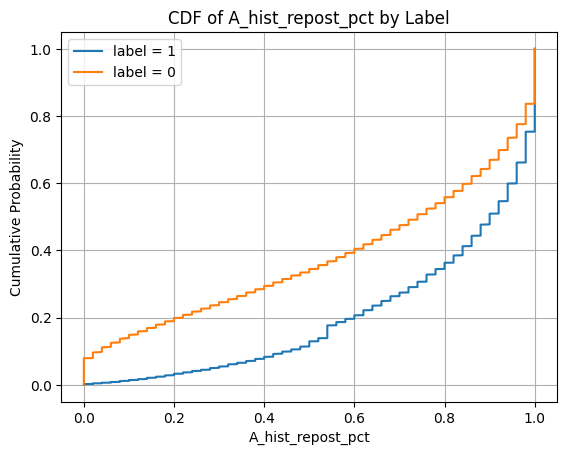

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cdf_A_hist_repost_pct(df):
    """
    Plots the cumulative distribution function (CDF)
    of A_hist_repost_pct for label=1 and label=0.
    """

    # Remove missing values
    df_clean = df.dropna(subset=["A_hist_repost_pct", "label"])

    # Split by label
    pos = df_clean[df_clean["label"] == 1]["A_hist_repost_pct"].values
    neg = df_clean[df_clean["label"] == 0]["A_hist_repost_pct"].values

    # Sort
    pos_sorted = np.sort(pos)
    neg_sorted = np.sort(neg)

    # Compute empirical CDF
    pos_cdf = np.arange(1, len(pos_sorted) + 1) / len(pos_sorted) if len(pos_sorted) > 0 else None
    neg_cdf = np.arange(1, len(neg_sorted) + 1) / len(neg_sorted) if len(neg_sorted) > 0 else None

    # Plot (single plot, no colors specified)
    plt.figure()

    if pos_cdf is not None:
        plt.plot(pos_sorted, pos_cdf)

    if neg_cdf is not None:
        plt.plot(neg_sorted, neg_cdf)

    plt.xlabel("A_hist_repost_pct")
    plt.ylabel("Cumulative Probability")
    plt.title("CDF of A_hist_repost_pct by Label")
    plt.legend(["label = 1", "label = 0"])
    plt.grid(True)
    plt.show()

plot_cdf_A_hist_repost_pct(df) # Note we have not made sure to excldue the "repost" in history (likey bias adding one to history for all with label=1)